## Demo for modelling single-channel PSF from SMLM data

#### Setup environment

In [1]:
import sys
sys.path.append("..")
from psflearning.psflearninglib import psflearninglib
from psflearning import io
from psflearning.makeplots import *
import tensorflow as tf

try:
    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('Running on GPU')
except:
    print('Running on CPU')

Running on GPU


#### Create psflearning object and load the config file
$\small\color{skyblue}{\mathrm{basefile}}$: config file with all parameters  
$\small\color{skyblue}{\mathrm{sysfile}}$: config file with microscope specific parameters  
For advanced user, pass in base file only as below to interact with all parameters:   
```python
    L.param = io.param.combine('config_base')
```

In [2]:
L = psflearninglib()
L.param = io.param.combine(basefile='config_base',psftype='insitu',channeltype='1ch',sysfile='smart_tirf')

#### Edit user defined parameters

In [ ]:
L.param.datapath = r'T:\projects\smart-microscope\data\DNA paint ruler\2025-07-15/'
L.param.keyword = '20R-ruler-0.1exp-TIRF-onlyZFocusLockDT5-noPol--2025-07-15_01-32-51' # keyword of the file name or the full file name without extension
L.param.savename =  L.param.datapath+'python/result_1ch/' + L.param.keyword
L.param.gain = 0.24
L.param.ccd_offset = 100
L.param.varname = 'Main/data'
L.param.option.insitu.stage_pos = 0.6 # micron, stage position relative to infocus at the coverslip
L.param.option.model.const_pupilmag = True
L.param.option.insitu.var_stagepos = False
L.param.option.insitu.stage_tilt = [0,0]
L.param.option.insitu.repeat = 2
L.param.option.insitu.z_range = 1.0
L.param.insitu.frame_range = [1000,1500]
L.param.batch_size = 1000 # lower this number if out of memory
L.param.option.imaging.emission_wavelength = 0.68 # micron
L.param.plotall = True

#### Start learning

In [4]:
images = L.load_data()

T:\projects\smart-microscope\data\DNA paint ruler\2025-07-15\20R-ruler-0.1exp-TIRF-onlyZFocusLockDT5-noPol--2025-07-15_01-32-51.h5
(500, 1000, 256)


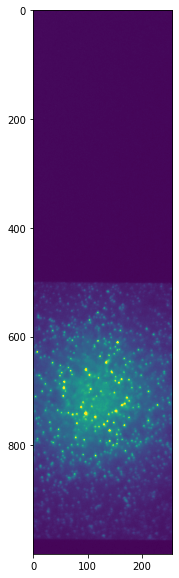

In [5]:
plt.figure(figsize=(10,10))
plt.imshow(images[0],clim=(0, np.quantile(images,0.999)))

Image size: (256, 256)


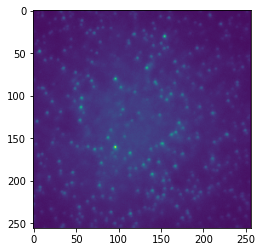

In [6]:
imsz = 256
startx = 0
starty = 580
plt.imshow(images[0][starty:starty+imsz,startx:startx+imsz])
print('Image size:', images[0][starty:starty+imsz,startx:startx+imsz].shape)

In [7]:
L.param.FOV.startx = startx
L.param.FOV.starty = starty
L.param.FOV.imsz = imsz
images = images[:,starty:starty+imsz,startx:startx+imsz]

rois shape channel : (17061, 13, 13)


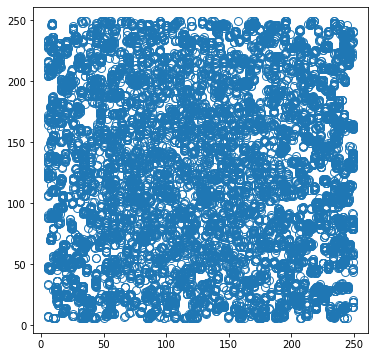

In [8]:
L.getpsfclass()
L.param.roi.roi_size = [13,13]
L.param.roi.peak_height = 0.1
dataobj = L.prep_data(images)

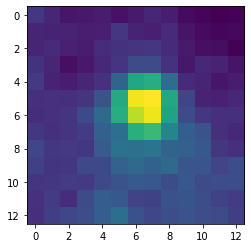

In [9]:
plt.imshow(dataobj.rois[40])

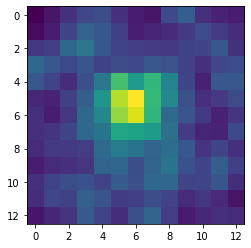

In [10]:
plt.imshow(np.max(dataobj.rois, axis=0))

4/6: calculating spline coefficients: 1/1 [00:00s]  3.46it/s total time: 0.29s
5/6: localization: 2/2 [00:00s]  6.30it/s total time: 0.60s
4/6: calculating spline coefficients: 1/1 [00:00s]  3.38it/s total time: 0.88s
5/6: localization: 2/2 [00:00s] 23.07it/s total time: 0.97s
4/6: calculating spline coefficients: 1/1 [00:00s]  3.36it/s total time: 1.26s
5/6: localization: 2/2 [00:00s] 23.62it/s total time: 1.35s
4/6: calculating spline coefficients: 1/1 [00:00s]  3.53it/s total time: 1.62s
5/6: localization: 2/2 [00:00s] 24.59it/s total time: 1.70s
4/6: calculating spline coefficients: 1/1 [00:00s]  3.62it/s total time: 1.97s
5/6: localization: 2/2 [00:00s] 19.74it/s total time: 2.07s
4/6: calculating spline coefficients: 1/1 [00:00s]  3.47it/s total time: 2.35s
5/6: localization: 2/2 [00:00s] 18.22it/s total time: 2.45s
4/6: calculating spline coefficients: 1/1 [00:00s]  3.40it/s total time: 2.73s
5/6: localization: 2/2 [00:00s] 19.32it/s total time: 2.84s
4/6: calculating spline coe

outlier percentage: 0.24
rois shape channel : (760, 13, 13)


3/6: learning: 214/250 [00:28s]  7.64it/s, current loss: 1.34973, total time: 103.98s   
4/6: calculating spline coefficients: 1/1 [00:00s]  3.64it/s total time: 0.27s
5/6: localization: 2/2 [00:00s] 48.32it/s total time: 0.32s
6/6: saving results: [00:00s] total time: 1.19s


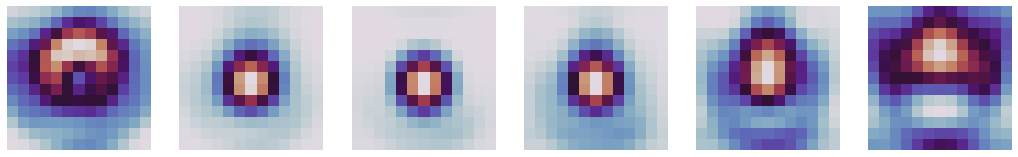

4/6: calculating spline coefficients: 1/1 [00:00s]  3.59it/s total time: 0.27s
5/6: localization: 2/2 [00:00s] 11.02it/s total time: 0.45s
3/6: learning: 282/? [01:12s]  3.88it/s, current loss: 1.65512, total time: 72.63s    


outlier percentage: 0.235
rois shape channel : (765, 13, 13)


3/6: learning: 153/250 [00:20s]  7.29it/s, current loss: 1.37766, total time: 93.62s
4/6: calculating spline coefficients: 1/1 [00:00s]  3.49it/s total time: 0.29s
5/6: localization: 2/2 [00:00s] 32.53it/s total time: 0.35s
6/6: saving results: [00:01s] total time: 2.01s


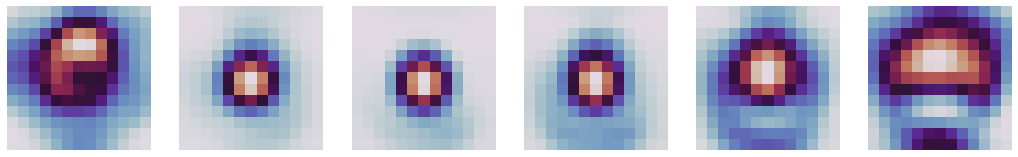

In [11]:
resfile = L.iterlearn_psf(dataobj,time=0)

#### Show results

In [19]:
f,p = io.h5.load(resfile) # load result file

In [13]:
f.res.sigma

array([0.5589847 , 0.01303128], dtype=float32)

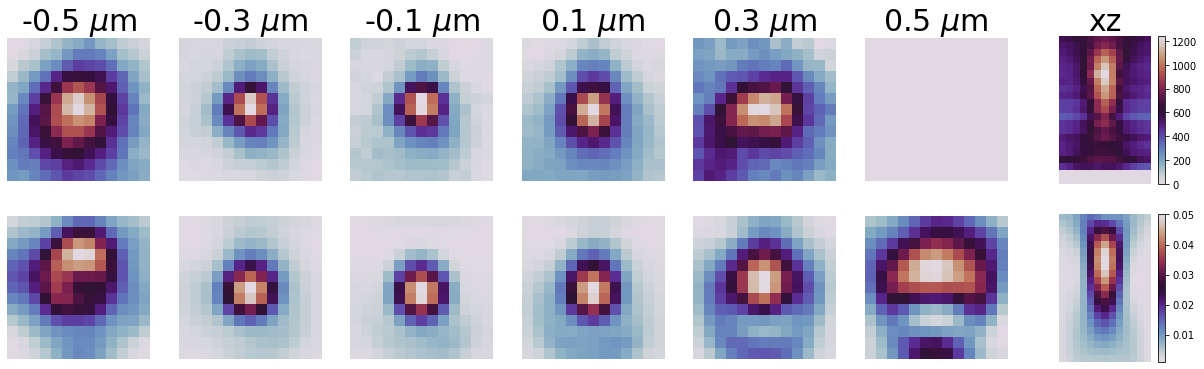

In [14]:
showpsfvsdata_insitu(f,p)

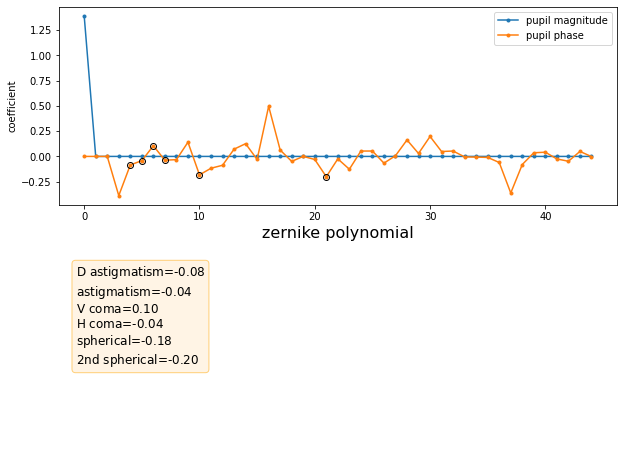

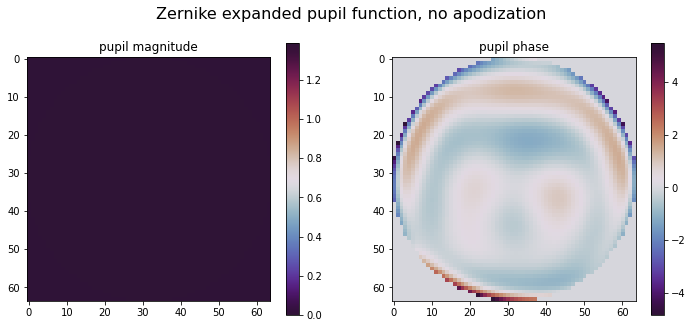

In [15]:
try:
    showzernike(f,p)
except:
    try: 
        showpupil(f,p)
    except:
        print('no pupil')

##### Optional plots

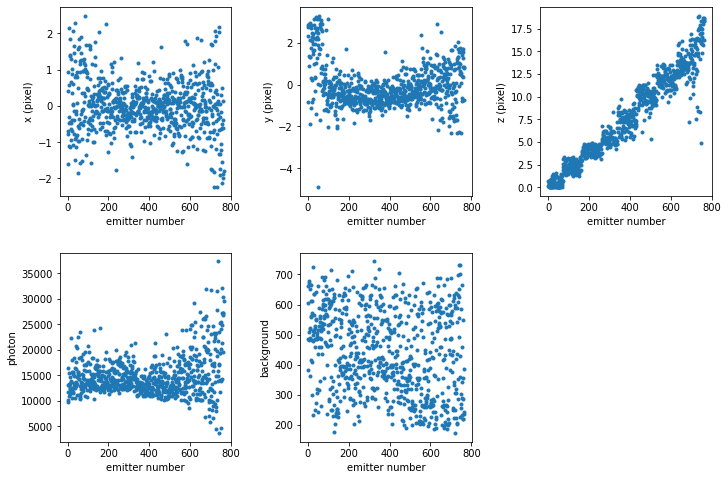

In [16]:
showlearnedparam_insitu(f,p)

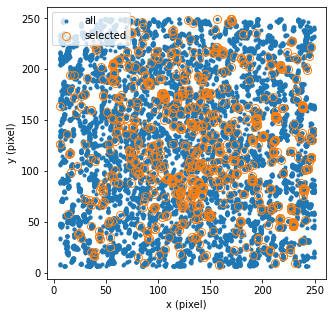

In [17]:
showcoord(f,p)

#### Ouput parameters

In [11]:
print('f:\n    ',list(f.keys()))
print(' locres:\n    ',list(f.locres.keys()))
print(' res:\n    ',list(f.res.keys()))
print(' rois:\n    ',list(f.rois.keys()))

f:
     ['locres', 'res', 'rois']
 locres:
     ['CRLB', 'LL', 'P', 'coeff', 'coeff_bead', 'coeff_reverse', 'loc']
 res:
     ['I_model', 'apodization', 'bg', 'cor', 'cor_all', 'intensity', 'offset', 'pos', 'pupil', 'sigma', 'stagepos', 'stagetilt', 'zernike_coeff', 'zernike_polynomial', 'zoffset']
 rois:
     ['cor', 'fileID', 'image_size', 'psf_data', 'psf_fit']
